Anusha Sundar 7.22.2026



**Context:**
One of the most interesting tasks in deep learning is to recognize objects in natural scenes. The ability to process visual information using machine learning algorithms can be very useful as demonstrated in various applications.

The SVHN dataset contains over 600,000 labeled digits cropped from street-level photos. It is one of the most popular image recognition datasets. It has been used in neural networks created by Google to improve the map quality by automatically transcribing the address numbers from a patch of pixels. The transcribed number with a known street address helps pinpoint the location of the building it represents.



**Objective:**
Our objective is to predict the number depicted inside the image by using Artificial or Fully Connected Feed Forward Neural Networks and Convolutional Neural Networks. We will go through various models of each and finally select the one that is giving us the best performance.



**Dataset:**
Our dataset is present in .h5 format. We will use a subset of our dataset to save ourselves a lot of computation time.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import h5py


# For Data Visualization
import cv2
import seaborn as sns

# For Model Building
import tensorflow as tf
import keras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential, Model # Sequential API for sequential model
from tensorflow.keras.layers import Dense, Dropout, Flatten # Importing different layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, Input, LeakyReLU, Activation
from tensorflow.keras import backend
from tensorflow.keras.utils import to_categorical # To perform one-hot encoding
from tensorflow.keras.optimizers import RMSprop, Adam, SGD # Optimizers for optimizing the model
from tensorflow.keras.callbacks import EarlyStopping  # Regularization method to prevent the overfitting
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import losses, optimizers
from tensorflow.keras.preprocessing.image import load_img
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Storing the path of the data file from the Google drive
data = '/content/drive/MyDrive/Colab Notebooks/SVHN_single_grey1 (1).h5'
categories = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
image_size = 150

In [ ]:
# Open the file in read-only mode
with h5py.File('/content/drive/MyDrive/Colab Notebooks/SVHN_single_grey1 (1).h5', 'r') as f:
    # 1. Check what datasets are inside the file
    print("Available keys:", list(f.keys()))

Available keys: ['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']


In [ ]:
h5_path = '/content/drive/MyDrive/Colab Notebooks/SVHN_single_grey1 (1).h5'
with h5py.File(h5_path, 'r') as f:

  X_train = f['X_train'][:]
  y_train = f['y_train'][:]
  X_val   = f['X_val'][:]
  y_val   = f['y_val'][:]
  X_test  = f['X_test'][:]
  y_test  = f['y_test'][:]

In [ ]:
# Save all arrays into a single compressed .npz zip file
np.savez_compressed('SVHN_data.npz',
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test)

In [ ]:
# TRAIN data creation
def load_svhn_training_data(archive_path):
   # Load the compressed npz zip archive
    data = np.load(archive_path)
    # Extract the individual arrays into variables
    X_train = data['X_train']
    y_train = data['y_train']

    print(f"Successfully processed {X_train.shape[0]} images!")

    return X_train, y_train
# Call function and assign output values to variables
    X_train, y_train = load_svhn_training_data('/content/SVHN_data_fixed.npz')

#print training data
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("First label entry:", y_train[0])


Training images shape: (42000, 32, 32)
Training labels shape: (42000,)
First label entry: 2


In [ ]:
# Add a channel dimension for grayscale (42000, 32, 32, 1)
X_train_cnn = X_train[..., None]

# Normalize pixel values from [0, 255] to [0.0, 1.0] for stable training
X_train_cnn = X_train_cnn / 255.0

In [ ]:
#repeat for TEST data creation

def load_svhn_training_data(archive_path):
   # Load the compressed npz zip archive
    data = np.load(archive_path)
    # Extract the individual arrays into variables
    X_test = data['X_test']
    y_test = data['y_test']

    print(f"Successfully processed {X_test.shape[0]} images!")

    return X_test, y_test
# Call function and assign output values to variables
    X_test, y_test = load_svhn_training_data('/content/SVHN_data_fixed.npz')

#print training data
print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("First label entry:", y_test[0])

Test images shape: (18000, 32, 32)
Test labels shape: (18000,)
First label entry: 1


In [ ]:
# Add a channel dimension for grayscale (42000, 32, 32, 1)
X_test_cnn = X_test[..., None]

# Normalize pixel values from [0, 255] to [0.0, 1.0] for stable testing
X_test_cnn = X_test_cnn / 255.0

In [ ]:
print(f"{data}/{categories[0]}")

/content/drive/MyDrive/Colab Notebooks/SVHN_single_grey1 (1).h5/zero


In [ ]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique labels in y_test: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
print("Unique labels in y_train:", np.unique(X_train))
print("Unique labels in y_test:", np.unique(X_test))

Unique labels in y_train: [0.000000e+00 1.140000e-01 2.280000e-01 ... 2.547465e+02 2.548605e+02
 2.549745e+02]
Unique labels in y_test: [0.000000e+00 1.140000e-01 2.989000e-01 ... 2.547465e+02 2.548605e+02
 2.549745e+02]


In [ ]:
print("First 10 training labels:", y_train[:10])


First 10 training labels: [2 6 7 4 4 0 3 0 7 3]


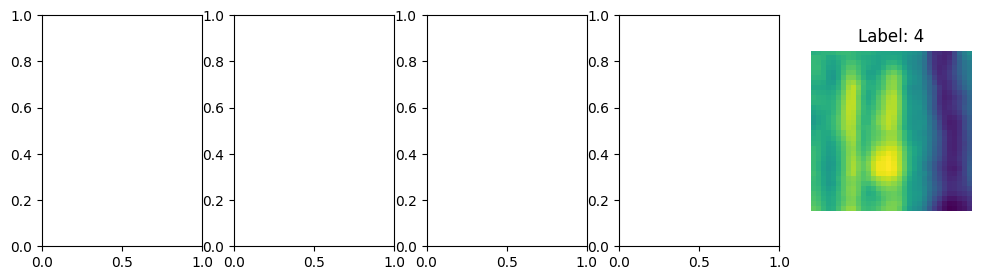

In [ ]:
# Plot the first 5 images and their corresponding labels

plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)

    img = X_train[i]

# Valid values for images (e.g., 0-255 for uint8 [unsigned 8-bit integer] or 0-1 for float)
if img.max() > 1.0:
        img = img.astype(np.uint8)
plt.imshow(img)

# Get the label
label = y_train[i]

plt.title(f"Label: {label}")
plt.axis('off')
plt.show()


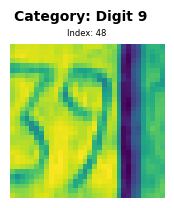

{np.uint8(0): np.int64(4186), np.uint8(1): np.int64(4172), np.uint8(2): np.int64(4197), np.uint8(3): np.int64(4281), np.uint8(4): np.int64(4188), np.uint8(5): np.int64(4232), np.uint8(6): np.int64(4168), np.uint8(7): np.int64(4192), np.uint8(8): np.int64(4188), np.uint8(9): np.int64(4196)}


In [ ]:
# Filter and Plot by Category
# Why flatten? Before flatten: [[1], [5], [3], [7]]
      # (Shape is 2D: 4 rows, 1 column)
      # After flatten: [1, 5, 3, 7] (Shape is 1D: a simple list of 4 numbers)

for digit in range(10):
  matching_indices = np.where(y_train.flatten() == digit)[0]

plt.figure(figsize=(5, 2))
plt.suptitle(f"Category: Digit {digit}", fontsize = 10, fontweight='bold', y=1.05)

img_index = matching_indices[i]
img = X_train[img_index]

if img.max() > 1.0:
    img = img.astype(np.uint8)


plt.imshow(img)
plt.axis('off')
plt.title(f"Index: {img_index}", fontsize=6)

plt.show()


digits, counts = np.unique(y_train, return_counts=True)
category_counts = dict(zip(digits, counts))
print(category_counts)


In [ ]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
import torch

# Convert NumPy array to Torch tensor
train_tensor = torch.tensor(X_train, dtype=torch.float32)

# Add channel dimension if grayscale
if train_tensor.ndim == 3:
    train_tensor = train_tensor.unsqueeze(1)   # (N,1,H,W)

# Scale to [0,1] if needed
if train_tensor.max() > 1:
    train_tensor = train_tensor / 255.0

mean = train_tensor.mean(dim=(0, 2, 3))
std  = train_tensor.std(dim=(0, 2, 3))

print("Mean:", mean)
print("Std :", std)

Mean: tensor([0.4403])
Std : tensor([0.1950])


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4403,),
        std=(0.1950,)
    )
])

X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0

mean = 0.4403
std = 0.1950

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

In [ ]:
# 1. Create TensorDatasets for each split

from torch.utils.data import TensorDataset, DataLoader

import torch

# 1. Convert Feature Images (X) to float32 tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# 2. Convert Labels (y) to long (int64) tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [ ]:
# initialize model building
import torch
import torch.nn as nn

class SVHNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(SVHNClassifier, self).__init__()

        #Block 1 Convolution + Pooling
        # Separates the tasks.
        #The convolution extracts fine-grained features first.
        #The pooling layer then summarizes those features in a separate step.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)


        #Block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        #Block 3         # Block 3: Input 64x8x8 --> Output 128x4x4
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Non-linearity
        self.relu = nn.ReLU()
        # 2x2 window & max-value
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

         # Fully Connected Layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        # Flatten the feature maps
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

def build_svhn_bb_model(input_shape=(128, 128, 3)):
    # Base Network
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    # --- Branch 1: Bounding Box Regression (4 coordinates) ---
    bbox_output = Dense(4, name="bbox_output")(x)

    # --- Branch 2: Digit Classification (10 classes: 0-9) ---
    class_output = Dense(10, activation='softmax', name="class_output")(x)

    # Define multi-output model
    model = Model(inputs=inputs, outputs=[bbox_output, class_output])
    return model

model = build_svhn_bb_model()

# Compile the model with dual loss functions
model.compile(
    optimizer='adam',
    loss={
        'bbox_output': 'mean_squared_error',
        'class_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'bbox_output': 1.0,
        'class_output': 1.0
    },
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 126, 126,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 63, 63,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 30,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 14, 14,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        516 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 10)        │      1,290 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,306,446 (12.61 MB)

 Trainable params: 3,306,446 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Initialize network, loss function, and optimizer
import torch.optim as optim

learning_rate = 0.001 #default for Adam optimizers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  #detects fastest hardware available to process code
model = SVHNClassifier(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  #need 'lr = ' to set up optional lr parameter after required

In [ ]:
def train_and_evaluate():
  for epoch in range(16):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            # Add channel dimension if missing (N, H, W) -> (N, 1, H, W)
            if images.ndim == 3:
                images = images.unsqueeze(1)
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Evaluation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                # Add channel dimension if missing (N, H, W) -> (N, 1, H, W)
                if images.ndim == 3:
                    images = images.unsqueeze(1)
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        print(f"Epoch [{epoch+1}/{16}] | Train Loss: {epoch_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

# Execute the pipeline
if __name__ == "__main__":
    train_and_evaluate()

Epoch [1/16] | Train Loss: 1.3443 | Test Accuracy: 84.36%
Epoch [2/16] | Train Loss: 0.8175 | Test Accuracy: 87.87%
Epoch [3/16] | Train Loss: 0.7194 | Test Accuracy: 89.89%
Epoch [4/16] | Train Loss: 0.6598 | Test Accuracy: 89.47%
Epoch [5/16] | Train Loss: 0.6112 | Test Accuracy: 90.16%
Epoch [6/16] | Train Loss: 0.5814 | Test Accuracy: 91.07%
Epoch [7/16] | Train Loss: 0.5462 | Test Accuracy: 91.47%
Epoch [8/16] | Train Loss: 0.5327 | Test Accuracy: 90.80%
Epoch [9/16] | Train Loss: 0.5102 | Test Accuracy: 91.73%
Epoch [10/16] | Train Loss: 0.4837 | Test Accuracy: 91.64%
Epoch [11/16] | Train Loss: 0.4669 | Test Accuracy: 91.74%
Epoch [12/16] | Train Loss: 0.4189 | Test Accuracy: 92.18%
Epoch [13/16] | Train Loss: 0.3853 | Test Accuracy: 92.26%
Epoch [14/16] | Train Loss: 0.3668 | Test Accuracy: 91.82%
Epoch [15/16] | Train Loss: 0.3511 | Test Accuracy: 92.69%
Epoch [16/16] | Train Loss: 0.3436 | Test Accuracy: 92.49%
